In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
df = pd.read_csv("dataset.csv")

In [ ]:
print(df.shape)

(253, 15155)


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
print(df.shape)

(253, 15155)


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
X_scaled = StandardScaler().fit_transform(X)
n_features = X.shape[1]
n_samples = X.shape[0]

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y_encoded)

print("Après SMOTE:")
print(np.bincount(y_res))


Après SMOTE:
[162 162]


decision tree


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.4, random_state=42)


Accuracy: 0.9230769230769231

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92        63
           1       0.94      0.91      0.92        67

    accuracy                           0.92       130
   macro avg       0.92      0.92      0.92       130
weighted avg       0.92      0.92      0.92       130

Confusion Matrix:
 [[59  4]
 [ 6 61]]


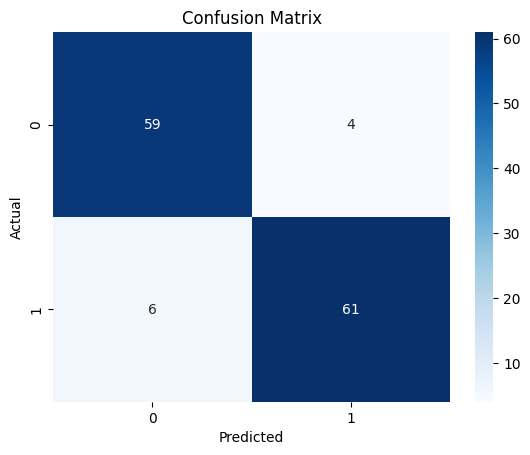

In [ ]:


dt_model = DecisionTreeClassifier(random_state=42)


dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Top 10 Features ===
           Feature  Importance
2236   MZ435.07512    0.939188
2921   MZ742.62632    0.040395
6935   MZ4187.5856    0.020417
10181  MZ9025.8805    0.000000
10096  MZ8875.7837    0.000000
10097  MZ8877.5422    0.000000
10098  MZ8879.3009    0.000000
10099  MZ8881.0598    0.000000
10100  MZ8882.8188    0.000000
10101   MZ8884.578    0.000000


/tmp/ipykernel_25061/1816276124.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


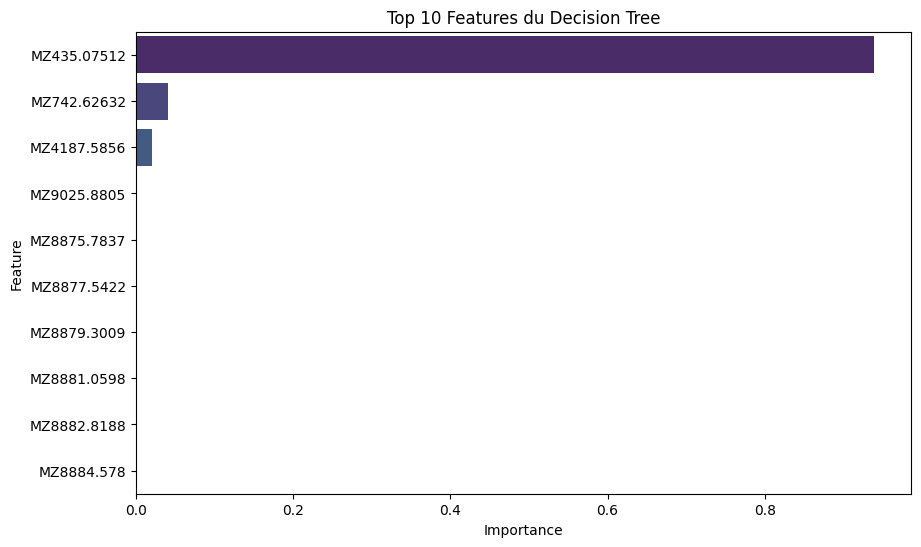

In [ ]:

importances = dt_model.feature_importances_
feature_names = X.columns


feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)


top_features = feat_imp_df.head(10)
print("=== Top 10 Features ===")
print(top_features)


plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title("Top 10 Features du Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

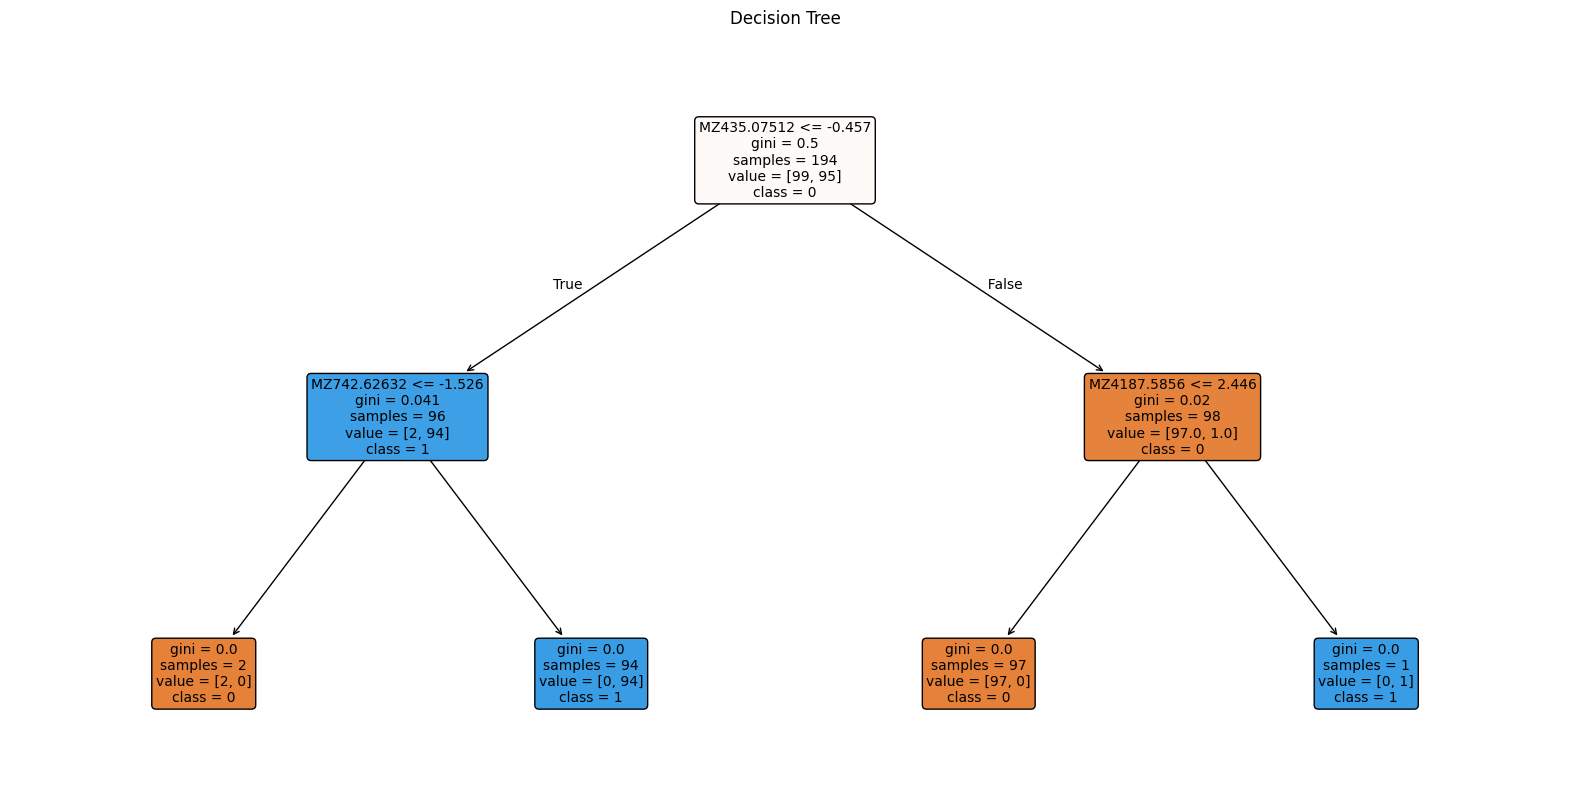

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree")
plt.show()



Rondom Forest



Accuracy: 0.9923076923076923

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        63
           1       0.99      1.00      0.99        67

    accuracy                           0.99       130
   macro avg       0.99      0.99      0.99       130
weighted avg       0.99      0.99      0.99       130



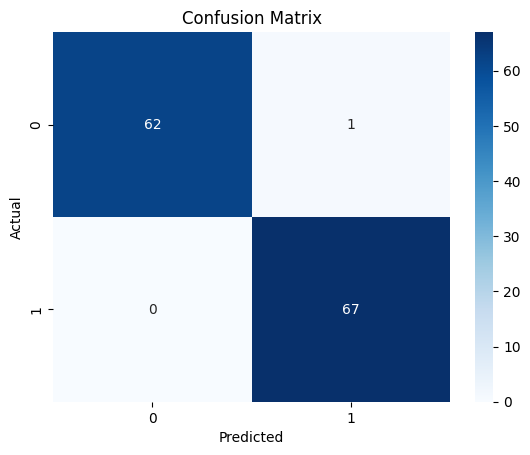


=== All Selected Features by Random Forest (Importance > 0) ===
           Feature  Importance
1678   MZ244.95245    0.035148
2308   MZ463.55767    0.031436
2191   MZ417.73207    0.025592
1685   MZ247.00158    0.025158
2309   MZ463.95962    0.023738
...            ...         ...
6373   MZ3536.2919    0.000105
12858  MZ14397.014    0.000103
228    MZ4.4898597    0.000101
13146  MZ15049.229    0.000066
1697   MZ250.53422    0.000039

[535 rows x 2 columns]

Number of selected features: 535
['MZ244.95245', 'MZ463.55767', 'MZ417.73207', 'MZ247.00158', 'MZ463.95962', 'MZ245.8296', 'MZ261.58446', 'MZ435.07512', 'MZ247.295', 'MZ464.36174', 'MZ220.75125', 'MZ435.46452', 'MZ224.09159', 'MZ2.7921478', 'MZ244.66041', 'MZ246.12233', 'MZ246.70832', 'MZ245.24466', 'MZ435.85411', 'MZ14504.713', 'MZ434.29682', 'MZ418.8773', 'MZ464.76404', 'MZ3535.1821', 'MZ436.24386', 'MZ222.41828', 'MZ436.63379', 'MZ465.56916', 'MZ29.001246', 'MZ437.0239', 'MZ25.589892', 'MZ29.202625', 'MZ244.07686', 'MZ462.7543', 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.4, random_state=42)

# Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)


selected_features = feat_imp_df[feat_imp_df['Importance'] > 0]

print("\n=== All Selected Features by Random Forest (Importance > 0) ===")
print(selected_features)

print("\nNumber of selected features:", len(selected_features))

rf_selected_list = selected_features['Feature'].tolist()
print(rf_selected_list)


LASSO


In [ ]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=3, max_iter=5000)
lasso.fit(X_train, y_train)

print("Best alpha:", lasso.alpha_)

Best alpha: 0.001055515564504699


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.220e-03, tolerance: 4.848e-03
  model = cd_fast.enet_coordinate_descent(
/tmp/ipykernel_25061/691343215.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AbsCoefficient', y='Feature', data=top_features, palette='magma')


=== Features sélectionnées par LASSO ===
142
['MZ245.24466', 'MZ435.07512', 'MZ2.7921478', 'MZ2.8548732', 'MZ224.09159', 'MZ555.30262', 'MZ18.353113', 'MZ280.63566', 'MZ2663.4704', 'MZ788.5851', 'MZ248.47046', 'MZ193.63068', 'MZ3674.132', 'MZ12.38191', 'MZ437.0239', 'MZ200.97123', 'MZ237.12862', 'MZ7560.432', 'MZ3.2795711', 'MZ544.79675', 'MZ191.04215', 'MZ11.353361', 'MZ462.35287', 'MZ319.74476', 'MZ4492.4847', 'MZ3673.0007', 'MZ1.9871526', 'MZ0.059102413', 'MZ15.221106', 'MZ130.28013', 'MZ4.7302923', 'MZ3.4855143', 'MZ5.6655283', 'MZ3254.6602', 'MZ21.001059', 'MZ2.9824141', 'MZ891.87356', 'MZ3539.6225', 'MZ9.8355253', 'MZ675.54728', 'MZ1.3187212', 'MZ90.08954', 'MZ4.2172807', 'MZ1.6358664', 'MZ549.162', 'MZ0.000366014', 'MZ7.4795111', 'MZ1.7574065', 'MZ3.0798987', 'MZ415.44632', 'MZ0.004328805', 'MZ8.1578277', 'MZ269.49216', 'MZ13.047398', 'MZ1.8324209', 'MZ789.10933', 'MZ3.9532369', 'MZ269.79865', 'MZ6.879501', 'MZ351.53717', 'MZ6.8306324', 'MZ6605.8898', 'MZ17097.441', 'MZ3540.7331

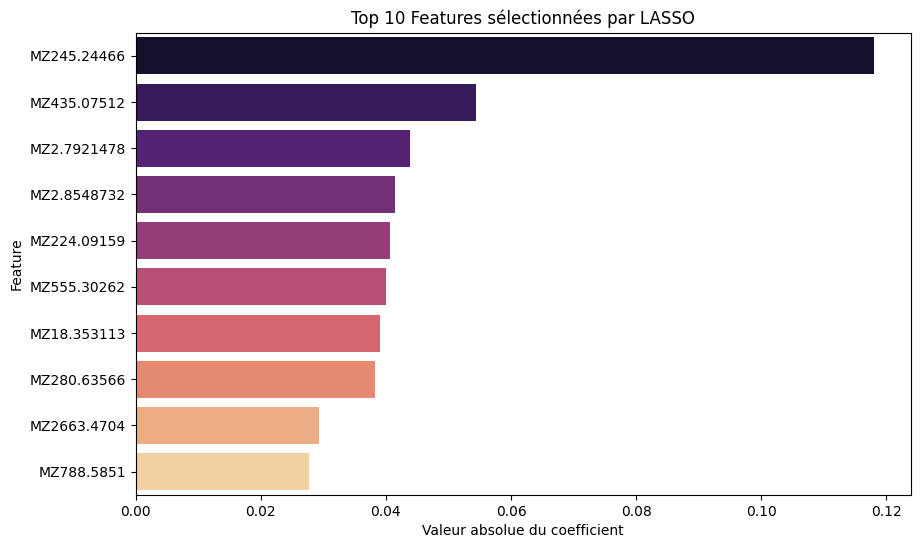

=== Metrics d'évaluation ===
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-score : 1.0

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        67

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130


=== Confusion Matrix ===
[[63  0]
 [ 0 67]]


In [ ]:
from sklearn.linear_model import Lasso

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.4, random_state=42)


lasso = Lasso(alpha=0.001055515564504699)
lasso.fit(X_train, y_train)

coef = lasso.coef_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
feat_imp_df['AbsCoefficient'] = np.abs(feat_imp_df['Coefficient'])
feat_imp_df = feat_imp_df.sort_values(by='AbsCoefficient', ascending=False)


selected_features = feat_imp_df[feat_imp_df['Coefficient'] != 0]['Feature'].tolist()
print("=== Features sélectionnées par LASSO ===")
print(len(selected_features))
print(selected_features)


top_features = feat_imp_df.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='AbsCoefficient', y='Feature', data=top_features, palette='magma')
plt.title("Top 10 Features sélectionnées par LASSO")
plt.xlabel("Valeur absolue du coefficient")
plt.ylabel("Feature")
plt.show()



from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_pred = lasso.predict(X_test)

y_pred_class = (y_pred > 0.5).astype(int)

print("=== Metrics d'évaluation ===")
print("Accuracy :", accuracy_score(y_test, y_pred_class))
print("Precision :", precision_score(y_test, y_pred_class))
print("Recall :", recall_score(y_test, y_pred_class))
print("F1-score :", f1_score(y_test, y_pred_class))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_class))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_class))

SVM-RFE

=== Features sélectionnées par SVM-RFE ===
['MZ2.8234234', 'MZ2.8548732', 'MZ2.8864971', 'MZ245.24466', 'MZ245.53704', 'MZ262.49088', 'MZ434.29682', 'MZ434.68588', 'MZ435.07512', 'MZ555.74254']
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00        33
      Normal       1.00      1.00      1.00        18

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51

Confusion Matrix:
 [[33  0]
 [ 0 18]]


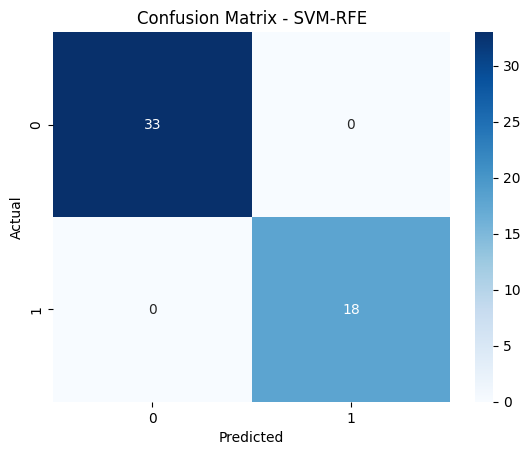

In [ ]:
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


svm = SVC(kernel='linear', C=1.0, random_state=42)


rfe = RFE(estimator=svm, n_features_to_select=10, step=1)
rfe.fit(X_train, y_train)


selected_features = X.columns[rfe.support_].tolist()
print("=== Features sélectionnées par SVM-RFE ===")
print(selected_features)


svm_final = SVC(kernel='linear', C=1.0, random_state=42)
svm_final.fit(X_train[selected_features], y_train)


y_pred = svm_final.predict(X_test[selected_features])


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM-RFE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from collections import Counter
import pandas as pd

dt_features = [
    "MZ435.07512",
    "MZ742.62632",
    "MZ4187.5856",
    "MZ9025.8805",
    "MZ8875.7837",
    "MZ8877.5422",
    "MZ8879.3009",
    "MZ8881.0598",
    "MZ8882.8188",
    "MZ8884.578"
]

rf_features = ['MZ244.95245', 'MZ463.55767', 'MZ417.73207', 'MZ247.00158', 'MZ463.95962',
               'MZ245.8296', 'MZ261.58446', 'MZ435.07512', 'MZ247.295', 'MZ464.36174', 'MZ220.75125',
               'MZ435.46452', 'MZ224.09159', 'MZ2.7921478', 'MZ244.66041', 'MZ246.12233', 'MZ246.70832',
               'MZ245.24466', 'MZ435.85411', 'MZ14504.713', 'MZ434.29682', 'MZ418.8773', 'MZ464.76404',
               'MZ3535.1821', 'MZ436.24386', 'MZ222.41828', 'MZ436.63379', 'MZ465.56916', 'MZ29.001246',
               'MZ437.0239', 'MZ25.589892', 'MZ29.202625', 'MZ244.07686', 'MZ462.7543', 'MZ28.700483',
               'MZ252.01356', 'MZ42.438773', 'MZ3557.4122', 'MZ224.65076', 'MZ4004.826', 'MZ251.71735', 'MZ4185.1703', 'MZ629.30973', 'MZ8036.7312', 'MZ618.58656', 'MZ222.97536', 'MZ17019.433', 'MZ4744.889', 'MZ251.42131', 'MZ235.12095', 'MZ676.51788', 'MZ220.47402', 'MZ704.96826', 'MZ618.12243', 'MZ3558.5255', 'MZ410.51536', 'MZ16021.548', 'MZ4027.2999', 'MZ409.75936', 'MZ433.90794', 'MZ15145.551', 'MZ14488.982', 'MZ8043.4257', 'MZ646.75338', 'MZ223.81227', 'MZ14491.229', 'MZ8046.774', 'MZ8078.6173', 'MZ4761.6177', 'MZ4026.1155', 'MZ262.49088', 'MZ629.77804', 'MZ4015.4637', 'MZ4067.6733', 'MZ2.8864971', 'MZ34.244758', 'MZ681.86861', 'MZ27.611098', 'MZ14882.543', 'MZ8013.3226', 'MZ15908.348', 'MZ15858.949', 'MZ4002.464', 'MZ8118.9303', 'MZ14946.368', 'MZ8347.5606', 'MZ434.68588', 'MZ4925.2833', 'MZ680.89419', 'MZ418.11364', 'MZ247.88239', 'MZ15955.466', 'MZ554.4233', 'MZ417.35068', 'MZ705.46393', 'MZ15186.925', 'MZ2.8234234', 'MZ432.35414', 'MZ28.800563', 'MZ3164.7795', 'MZ5420.4978', 'MZ502.93907', 'MZ221.58398', 'MZ186.93673', 'MZ4903.04', 'MZ10511.699', 'MZ462.35287', 'MZ221.86191', 'MZ13.799553', 'MZ29.91294', 'MZ7996.6231', 'MZ12950.475', 'MZ13621.661', 'MZ8967.4582', 'MZ7659.7544', 'MZ5017.4036', 'MZ4014.281', 'MZ32.095097', 'MZ808.62827', 'MZ4996.2722', 'MZ28.500845', 'MZ7054.7171', 'MZ320.74681', 'MZ11024.931', 'MZ207.10313', 'MZ7998.2922', 'MZ2.8548732', 'MZ290.41236', 'MZ539.58144', 'MZ437.80463', 'MZ431.19062', 'MZ27.513109', 'MZ243.49401', 'MZ6.5889021', 'MZ540.88291', 'MZ255.88023', 'MZ878.54583', 'MZ7602.6869', 'MZ320.41262', 'MZ3162.6798', 'MZ280.32307', 'MZ461.14964', 'MZ4060.5339', 'MZ662.03209', 'MZ466.77814', 'MZ15861.299', 'MZ359.98622', 'MZ14812.04', 'MZ879.09915', 'MZ15896.579', 'MZ26.735461', 'MZ11032.771', 'MZ4436.3647', 'MZ17046.228', 'MZ38.059088', 'MZ6965.6408', 'MZ6803.0344', 'MZ245.53704', 'MZ7913.3866', 'MZ430.80313', 'MZ377.18533', 'MZ10149.37', 'MZ7871.9317', 'MZ246.41524', 'MZ3924.9084', 'MZ921.66105', 'MZ27.317652', 'MZ707.94485', 'MZ11574.479', 'MZ206.0301', 'MZ9105.8531', 'MZ40.278329', 'MZ4008.3703', 'MZ277.20675', 'MZ11101.496', 'MZ3559.639', 'MZ235.40723', 'MZ9001.0721', 'MZ223.25415', 'MZ570.35769', 'MZ682.35609', 'MZ14612.814', 'MZ25.873933', 'MZ418.49538', 'MZ4738.4627', 'MZ18.433162', 'MZ0.15400037', 'MZ27.906113', 'MZ24.747176', 'MZ0.17675811', 'MZ11223.759', 'MZ193.37104', 'MZ0.65997473', 'MZ3937.7816', 'MZ4028.4845', 'MZ26.159541', 'MZ64.272715', 'MZ8021.6789', 'MZ405.98983', 'MZ15950.751', 'MZ14839.312', 'MZ3167.9303', 'MZ563.69093', 'MZ5034.6056', 'MZ1268.9528', 'MZ467.98869', 'MZ319.0776', 'MZ621.84038', 'MZ15113.409', 'MZ4623.534', 'MZ9136.1568', 'MZ363.18048', 'MZ360.69484', 'MZ13502.112', 'MZ16251.533', 'MZ11340.729', 'MZ15092.765', 'MZ380.09086', 'MZ27.415293', 'MZ21.086681', 'MZ261.88643', 'MZ247.58861', 'MZ3547.4', 'MZ14511.458', 'MZ14907.601', 'MZ5087.7195', 'MZ8152.6011', 'MZ19955.943', 'MZ15814.32', 'MZ17007.26', 'MZ14.787324', 'MZ0.78685372', 'MZ677.97508', 'MZ7086.1061', 'MZ140.26433', 'MZ10502.133', 'MZ259.77633', 'MZ885.75256', 'MZ1689.2512', 'MZ15193.827', 'MZ6798.4167', 'MZ1577.6229', 'MZ7540.9695', 'MZ4080.7784', 'MZ19701.002', 'MZ234.54889', 'MZ7032.7863', 'MZ10458.185', 'MZ8134.0736', 'MZ334.25722', 'MZ14249.583', 'MZ402.23772', 'MZ10237.94', 'MZ11320.861', 'MZ53.813359', 'MZ14549.706', 'MZ3674.132', 'MZ6.9285438', 'MZ354.69381', 'MZ1416.6318', 'MZ16275.336', 'MZ9545.6236', 'MZ363.53627', 'MZ6681.9584', 'MZ272.87316', 'MZ0.64489871', 'MZ42.317268', 'MZ12.513614', 'MZ4716.6458', 'MZ38.637002', 'MZ553.9839', 'MZ348.39464', 'MZ7229.8056', 'MZ65.023076', 'MZ968.13067', 'MZ4813.2754', 'MZ3930.7572', 'MZ13658.72', 'MZ4750.0331', 'MZ14762.107', 'MZ15357.615', 'MZ483.8685', 'MZ59.429548', 'MZ14520.453', 'MZ8004.9707', 'MZ14444.083', 'MZ8145.8614', 'MZ169.25693', 'MZ359.63217', 'MZ0.11318798', 'MZ465.16651', 'MZ19588.512', 'MZ431.57829', 'MZ6801.495', 'MZ368.53561', 'MZ7.1264569', 'MZ243.78535', 'MZ8570.7234', 'MZ17097.441', 'MZ0.51705298', 'MZ506.29331', 'MZ3541.8438', 'MZ1338.3601', 'MZ0.96112942', 'MZ220.19696', 'MZ364.96117', 'MZ104.81963', 'MZ8354.3832', 'MZ11.165473', 'MZ3456.8278', 'MZ3018.4585', 'MZ834.30548', 'MZ550.91298', 'MZ4401.6236', 'MZ8040.0781', 'MZ1389.3663', 'MZ9155.7918', 'MZ7352.5241', 'MZ30.425534', 'MZ258.5744', 'MZ3948.33', 'MZ1831.7548', 'MZ4780.9567', 'MZ13552.041', 'MZ714.41563', 'MZ22.480329', 'MZ14932.68', 'MZ8.6996413', 'MZ11745.793', 'MZ555.74254', 'MZ14944.086', 'MZ7489.192', 'MZ14673.796', 'MZ15106.526', 'MZ15051.519', 'MZ913.74511', 'MZ280.01066', 'MZ11778.181', 'MZ5410.8828', 'MZ8390.2479', 'MZ16242.017', 'MZ7.7889223', 'MZ11302.995', 'MZ486.74677', 'MZ4814.5705', 'MZ12531.235', 'MZ16507.129', 'MZ327.46718', 'MZ17529.679', 'MZ17024.303', 'MZ8226.9222', 'MZ4003.6449', 'MZ11198.068', 'MZ2795.0994', 'MZ519.39631', 'MZ7252.0412', 'MZ6.6368998', 'MZ19374.887', 'MZ6.3986533', 'MZ670.70475', 'MZ11386.492', 'MZ6237.9742', 'MZ213.32718', 'MZ10789.069', 'MZ706.95196', 'MZ6799.9558', 'MZ14475.505', 'MZ673.12384', 'MZ758.47784', 'MZ784.92037', 'MZ958.8609', 'MZ243.20284', 'MZ2260.0402', 'MZ5836.3126', 'MZ4416.4959', 'MZ319.41109', 'MZ1698.4694', 'MZ1227.4106', 'MZ1497.8499', 'MZ48.605912', 'MZ8325.4062', 'MZ862.57535', 'MZ17440.828', 'MZ2160.8845', 'MZ13.31847', 'MZ15267.538', 'MZ2989.814', 'MZ5041.2296', 'MZ15067.552', 'MZ0.54424382', 'MZ4843.1048', 'MZ0.62999688', 'MZ14482.243', 'MZ3482.114', 'MZ403.36153', 'MZ619.51535', 'MZ328.48124', 'MZ829.46044', 'MZ17102.323', 'MZ1.3187212', 'MZ634.47077', 'MZ275.34532', 'MZ3103.1316', 'MZ18195.704', 'MZ17251.543', 'MZ292.96255', 'MZ965.80904', 'MZ2.2032161', 'MZ2.0135509', 'MZ1434.249', 'MZ16912.462', 'MZ6727.8086', 'MZ288.50703', 'MZ1748.837', 'MZ9369.555', 'MZ2529.3806', 'MZ7963.2762', 'MZ15221.448', 'MZ8035.0581', 'MZ3586.4155', 'MZ3166.8798', 'MZ5519.8905', 'MZ0.26393951', 'MZ16914.889', 'MZ15334.493', 'MZ14680.58', 'MZ279.07445', 'MZ15924.831', 'MZ194.41064', 'MZ3997.7421', 'MZ7046.8808', 'MZ3070.9833', 'MZ3477.7098', 'MZ7071.9724', 'MZ4609.5839', 'MZ17036.482', 'MZ8045.0997', 'MZ574.82397', 'MZ328.14305', 'MZ3916.7273', 'MZ15976.692', 'MZ2183.5021', 'MZ311.12603', 'MZ12.579727', 'MZ7.0767174', 'MZ7810.7782', 'MZ15851.898', 'MZ64.572337', 'MZ15099.645', 'MZ11586.531', 'MZ13992.3', 'MZ12.845923', 'MZ48.736127', 'MZ3651.5396', 'MZ252.30996', 'MZ3530.7444', 'MZ71.972287', 'MZ10975.99', 'MZ2531.2584', 'MZ6812.2745', 'MZ1688.4842', 'MZ16012.1', 'MZ9095.1697', 'MZ266.4368', 'MZ2252.0613', 'MZ785.96657', 'MZ4047.4614', 'MZ7065.6953', 'MZ1544.4383', 'MZ1148.9295', 'MZ10590.304', 'MZ437.41417', 'MZ9202.2858', 'MZ734.00462', 'MZ4016.6465', 'MZ11572.471', 'MZ51.243302', 'MZ1173.0965', 'MZ97.131193', 'MZ18491.471', 'MZ3554.0732', 'MZ303.27479', 'MZ1187.846', 'MZ19940.126', 'MZ3150.0963', 'MZ19227.083', 'MZ6587.6982', 'MZ3371.7608', 'MZ7503.7364', 'MZ4800.3349', 'MZ6034.7477', 'MZ1579.8478', 'MZ12114.784', 'MZ1935.4329', 'MZ540.44891', 'MZ425.7816', 'MZ415.82684', 'MZ3985.9494', 'MZ14700.941', 'MZ9664.5249', 'MZ306.53395', 'MZ4386.7763', 'MZ17909.815', 'MZ6248.2976', 'MZ1809.4556', 'MZ3799.6359', 'MZ9175.448', 'MZ13948.178', 'MZ3460.1208', 'MZ19038.615', 'MZ15019.477', 'MZ10855.087', 'MZ2804.976', 'MZ4167.0776', 'MZ1059.0247', 'MZ11123.139', 'MZ11468.297', 'MZ13541.179', 'MZ17278.52', 'MZ293.2821', 'MZ11520.325', 'MZ2095.4468', 'MZ375.73674', 'MZ726.94219', 'MZ388.50638', 'MZ5618.787', 'MZ18915.197', 'MZ13695.828', 'MZ13781.15', 'MZ427.70947', 'MZ3536.2919', 'MZ14397.014', 'MZ4.4898597', 'MZ15049.229', 'MZ250.53422']


lasso_features = ['MZ245.24466', 'MZ435.07512', 'MZ2.7921478', 'MZ2.8548732', 'MZ224.09159',
                  'MZ555.30262', 'MZ18.353113', 'MZ280.63566', 'MZ2663.4704', 'MZ788.5851', 'MZ248.47046',
                  'MZ193.63068', 'MZ3674.132', 'MZ12.38191', 'MZ437.0239', 'MZ200.97123', 'MZ237.12862',
                  'MZ7560.432', 'MZ3.2795711', 'MZ544.79675', 'MZ191.04215', 'MZ11.353361', 'MZ462.35287',
                  'MZ319.74476', 'MZ4492.4847', 'MZ3673.0007', 'MZ1.9871526', 'MZ0.059102413', 'MZ15.221106',
                  'MZ130.28013', 'MZ4.7302923', 'MZ3.4855143', 'MZ5.6655283', 'MZ3254.6602', 'MZ21.001059',
                  'MZ2.9824141', 'MZ891.87356', 'MZ3539.6225', 'MZ9.8355253', 'MZ675.54728', 'MZ1.3187212',
                  'MZ90.08954', 'MZ4.2172807', 'MZ1.6358664', 'MZ549.162', 'MZ0.000366014', 'MZ7.4795111',
                  'MZ1.7574065', 'MZ3.0798987', 'MZ415.44632', 'MZ0.004328805', 'MZ8.1578277', 'MZ269.49216',
                  'MZ13.047398', 'MZ1.8324209', 'MZ789.10933', 'MZ3.9532369', 'MZ269.79865', 'MZ6.879501',
                  'MZ351.53717', 'MZ6.8306324', 'MZ6605.8898', 'MZ17097.441', 'MZ3540.7331', 'MZ323.09101',
                  'MZ0.80349744', 'MZ5.9807836', 'MZ2.1481551', 'MZ14.715637', 'MZ6821.5208', 'MZ7307.7797',
                  'MZ1.8833013', 'MZ4.8528601', 'MZ5.0187225', 'MZ0.017192634', 'MZ0.54424382', 'MZ190.78426',
                  'MZ6.2577957', 'MZ7.1763707', 'MZ5966.7922', 'MZ6.0724242', 'MZ2672.1469', 'MZ2559.5086',
                  'MZ0.15400037', 'MZ10.5505', 'MZ3.6977283', 'MZ5.8446291', 'MZ508.39538', 'MZ8.0515552', 'MZ13.938573', 'MZ9.4300403', 'MZ153.60969', 'MZ9.8941485', 'MZ2.7301193', 'MZ277.5176', 'MZ1.0740559', 'MZ17087.681', 'MZ13.114905', 'MZ2253.8332', 'MZ7237.743', 'MZ16.03266', 'MZ5.7100422', 'MZ14.43063', 'MZ2.3154285', 'MZ12.980065', 'MZ13174.462', 'MZ509.23742', 'MZ6.1647616', 'MZ2.9182952', 'MZ0.010634432', 'MZ0.30368935', 'MZ190.52654', 'MZ89.029724', 'MZ5969.6761', 'MZ2.343917', 'MZ7.2767207', 'MZ10.369405', 'MZ17095.001', 'MZ508.81631', 'MZ15.883537', 'MZ0.51705298', 'MZ2080.0957', 'MZ0.31406228', 'MZ0.12609535', 'MZ1.2343791', 'MZ8.9212441', 'MZ2.18E-07', 'MZ1.1729515', 'MZ20.830337', 'MZ460.34835', 'MZ23.554829', 'MZ1.2973744', 'MZ4.255698', 'MZ6622.5876', 'MZ320.41262', 'MZ3.8426881', 'MZ3168.9809', 'MZ23.193876', 'MZ6604.3729', 'MZ8.8100943', 'MZ1.4280681', 'MZ7239.331']



all_features = dt_features + rf_features + lasso_features


feature_counts = Counter(all_features)


df_counts = pd.DataFrame(feature_counts.items(), columns=['Feature', 'Count'])


df_counts = df_counts.sort_values(by='Count', ascending=False)

print("=== Majority Count ===")
print(df_counts)


selected_features = df_counts[df_counts['Count'] >= 2]

print("\n=== Features sélectionnées (Count >= ) ===")
print(selected_features)
print(len(selected_features))


=== Majority Count ===
          Feature  Count
0     MZ435.07512      3
265    MZ3674.132      2
408   MZ1.3187212      2
115   MZ462.35287      2
398  MZ0.54424382      2
..            ...    ...
231      MZ3547.4      1
232   MZ14511.458      1
233   MZ14907.601      1
234   MZ5087.7195      1
224   MZ11340.729      1

[672 rows x 2 columns]

=== Features sélectionnées (Count >= ) ===
          Feature  Count
0     MZ435.07512      3
265    MZ3674.132      2
408   MZ1.3187212      2
115   MZ462.35287      2
398  MZ0.54424382      2
38     MZ437.0239      2
307   MZ17097.441      2
308  MZ0.51705298      2
147   MZ320.41262      2
26    MZ245.24466      2
195  MZ0.15400037      2
22    MZ2.7921478      2
21    MZ224.09159      2
135   MZ2.8548732      2
14


In [ ]:
selected_features.to_csv("FeaturesCommunvraaiEmbadded.csv", index=False)
from google.colab import files
files.download("FeaturesCommunvraaiEmbadded.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

selector = VarianceThreshold(0.02)

X_train_reduced = selector.fit_transform(X_train)
X_test_reduced = selector.transform(X_test)


In [ ]:
from sklearn.svm import SVC
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

svm = SVC(kernel='linear')

cv = StratifiedKFold(5)

rfecv = RFECV(
    estimator=svm,
    step=10,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

rfecv.fit(X_train_reduced, y_train)

RFECV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
      estimator=SVC(kernel='linear'), n_jobs=-1, scoring='accuracy', step=10)

In [ ]:
selected_features = X_train.columns[selector.get_support()][rfecv.support_].tolist()
print(selected_features)
print(len(selected_features))

['MZ0.37995783', 'MZ2.7610465', 'MZ2.7921478', 'MZ2.8234234', 'MZ2.8548732', 'MZ2.8864971', 'MZ2.9182952', 'MZ9.7770763', 'MZ18.353113', 'MZ18.513384', 'MZ244.36855', 'MZ244.66041', 'MZ244.95245', 'MZ245.24466', 'MZ245.53704', 'MZ262.18857', 'MZ262.49088', 'MZ262.79337', 'MZ433.90794', 'MZ434.29682', 'MZ434.68588', 'MZ555.74254', 'MZ556.18264', 'MZ2674.0769']
24


In [ ]:
from sklearn.svm import SVC

X_selected = X_train_reduced[:, rfecv.support_]

svm = SVC(kernel='linear')
svm.fit(X_selected, y_train)

y_pred = svm.predict(X_test_reduced[:, rfecv.support_])

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


print("Accuracy:", accuracy_score(y_test, y_pred))


print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

=== Classification Report ===
              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00        65
      Normal       1.00      1.00      1.00        37

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
weighted avg       1.00      1.00      1.00       102



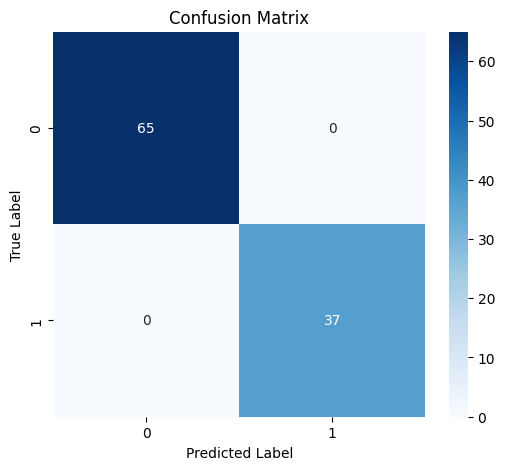

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
import pandas as pd

df1 = pd.read_csv("FeaturesCommunvraaiEmbadded (1).csv")
df2 = pd.read_csv("common_featuresEntreMIetChi2.csv")
df3 = pd.read_csv("selected_features wrapper.csv")


In [ ]:
df1 = df1.iloc[:, 0]
df2 = df2.iloc[:, 0]
df3 = df3.iloc[:, 0]


In [ ]:
s1 = set(df1)
s2 = set(df2)
s3 = set(df3)

In [ ]:
common = (s1 & s2) | (s1 & s3) | (s2 & s3)

In [ ]:
common_rows = pd.DataFrame(common, columns=["feature"])
print(common_rows)

        feature
0   MZ224.09159
1    MZ437.0239
2   MZ245.24466
3   MZ2.7921478
4   MZ435.07512
5  MZ0.15400037
6   MZ2.9182952
7   MZ2.8548732


In [ ]:
features_list = common_rows["feature"].tolist()

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report



In [ ]:
dfdatta = pd.read_csv("dataset.csv")

In [ ]:
dfdatta.shape

(253, 15155)

In [ ]:
features_list = [
 'MZ224.09159',
 'MZ437.0239',
 'MZ245.24466',
]

In [ ]:
dfdatta.columns

Index(['MZ-7.86E-05', 'MZ2.18E-07', 'MZ9.60E-05', 'MZ0.000366014',
       'MZ0.000810195', 'MZ0.001428564', 'MZ0.002221123', 'MZ0.003187869',
       'MZ0.004328805', 'MZ0.005643929',
       ...
       'MZ19974.404', 'MZ19977.042', 'MZ19979.68', 'MZ19982.319',
       'MZ19984.957', 'MZ19987.596', 'MZ19990.235', 'MZ19992.874',
       'MZ19995.513', 'Class'],
      dtype='object', length=15155)

In [ ]:
y = dfdatta["Class"]

X = dfdatta[features_list]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train.value_counts())

After SMOTE:
Class
Cancer    97
Normal    97
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
print("LR Accuracy:", accuracy_score(y_test, pred_lr))
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print("KNN Accuracy:", accuracy_score(y_test, pred_knn))
print("NB Accuracy:", accuracy_score(y_test, pred_nb))
print("DT Accuracy:", accuracy_score(y_test, pred_dt))
print("RF Accuracy:", accuracy_score(y_test, pred_rf))

LR Accuracy: 1.0
SVM Accuracy: 1.0
KNN Accuracy: 1.0
NB Accuracy: 0.9607843137254902
DT Accuracy: 0.9901960784313726
RF Accuracy: 0.9901960784313726


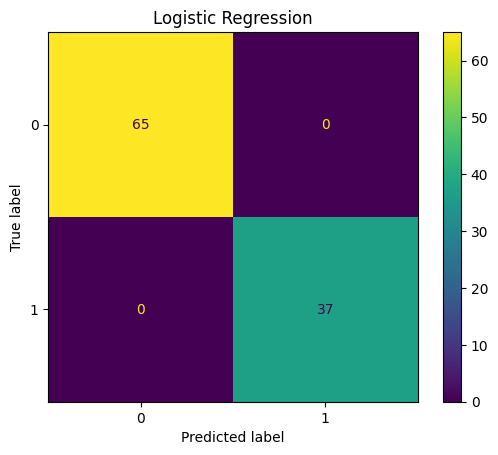

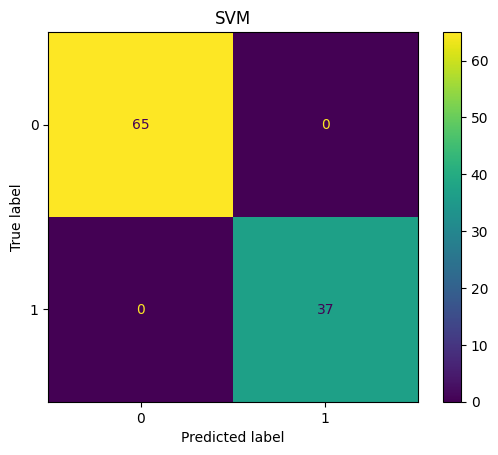

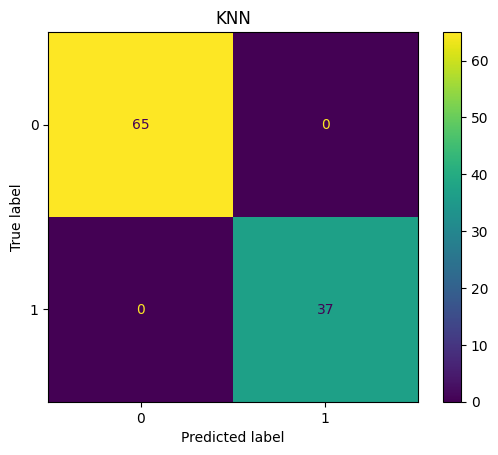

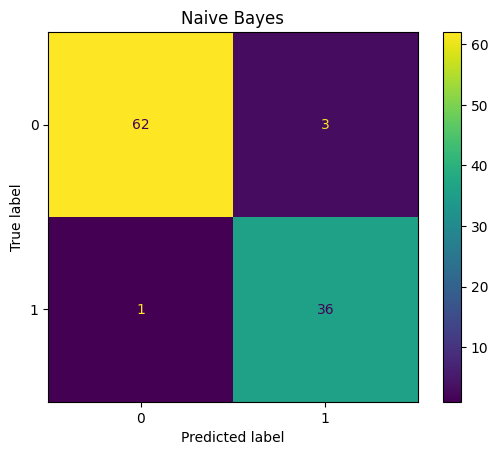

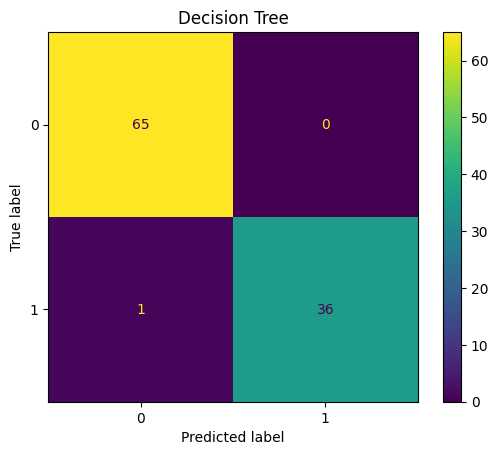

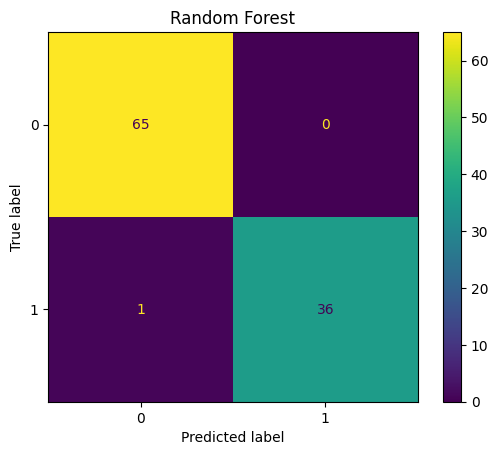

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_lr)).plot()
plt.title("Logistic Regression")
plt.show()


ConfusionMatrixDisplay(confusion_matrix(y_test, pred_svm)).plot()
plt.title("SVM")
plt.show()


ConfusionMatrixDisplay(confusion_matrix(y_test, pred_knn)).plot()
plt.title("KNN")
plt.show()


ConfusionMatrixDisplay(confusion_matrix(y_test, pred_nb)).plot()
plt.title("Naive Bayes")
plt.show()


ConfusionMatrixDisplay(confusion_matrix(y_test, pred_dt)).plot()
plt.title("Decision Tree")
plt.show()


ConfusionMatrixDisplay(confusion_matrix(y_test, pred_rf)).plot()
plt.title("Random Forest")
plt.show()